In [43]:
import pickle

# Path to the .pkl file
pkl_path = "/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_scratch/perlin/scratch_perlin_epoch_300.pckl"

# Load the contents of the file
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)


UnpicklingError: A load persistent id instruction was encountered,
but no persistent_load function was specified.

In [30]:
import argparse
import torch
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score
from models.DRAEM import ReconstructiveSubNetwork, DiscriminativeSubNetwork
from data.field_dataloader import FieldDataset
from tqdm import tqdm 

import glob
import os

from visualizations import display_images_side_by_side


In [31]:
test_root_dir = "/home/maria/Documents/dataset_splited/agco_dataset/test/"
resize_image = (256, 256*2)
batch_size = 1
reconstructive_checkpoint = 'checkpoints_scratch/realsyn/scratch_realsyn_real_epoch_101.pckl'
discriminative_checkpoint = '/home/maria/Documents/projects/anomaly_detection_vehicles/checkpoints_scratch/realsyn/scratch_realsyn_real_epoch_101_seg.pckl'

In [32]:
%%capture
test_dataset = FieldDataset(test_root_dir, resize_shape=resize_image)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=6)

model = ReconstructiveSubNetwork(in_channels=3, out_channels=3)
model.load_state_dict(torch.load(reconstructive_checkpoint, map_location='cpu'))
model.cpu()
model.eval()

model_seg = DiscriminativeSubNetwork(in_channels=6, out_channels=2)
model_seg.load_state_dict(torch.load(discriminative_checkpoint, map_location='cpu'))
model_seg.cpu()
model_seg.eval()


In [9]:
abnormal_images = sorted(glob.glob(os.path.join(test_root_dir, "abnormal", "*.png")))

In [5]:
abnormal_images

['/home/maria/Documents/dataset_splited/agco_dataset/test/abnormal/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_26_14_203.png',
 '/home/maria/Documents/dataset_splited/agco_dataset/test/abnormal/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_26_22_406.png',
 '/home/maria/Documents/dataset_splited/agco_dataset/test/abnormal/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_29_47_803.png',
 '/home/maria/Documents/dataset_splited/agco_dataset/test/abnormal/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_29_52_3.png',
 '/home/maria/Documents/dataset_splited/agco_dataset/test/abnormal/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_29_56_203.png',
 '/home/maria/Documents/dataset_splited/agco_dataset/test/abnormal/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_36_08_5.png',
 '/home/maria/Documents/dataset_splited/agco_dataset/test/abnormal/BNV61080I3001136_cam_flir_right_image_raw_2024_06_25_13_38_42_3.png',
 '/home/maria/Documents/dataset_s

In [33]:
%%capture
test_dataset = FieldDataset(test_root_dir, resize_shape=resize_image)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=6)

model = ReconstructiveSubNetwork(in_channels=3, out_channels=3)
model.load_state_dict(torch.load(reconstructive_checkpoint, map_location='cpu'))
model.cpu()
model.eval()

model_seg = DiscriminativeSubNetwork(in_channels=6, out_channels=2)
model_seg.load_state_dict(torch.load(discriminative_checkpoint, map_location='cpu'))
model_seg.cpu()
model_seg.eval()

In [34]:
import os
import glob
import torch
import numpy as np
from PIL import Image
from torchvision.transforms import transforms
from sklearn.metrics import roc_auc_score, average_precision_score



# Collect all abnormal images
abnormal_images = sorted(glob.glob(os.path.join(test_root_dir, "abnormal", "*.png")))

# Define a custom transformation class to handle RGBA to RGB conversion
class ConvertToRGB:
    def __call__(self, img):
        if img.mode == 'RGBA':
            img = img.convert('RGB')  
        return img

# Transformation pipeline
transform_trained = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((256, 256 * 2)),
    transforms.ToTensor(),
])



In [35]:
# Initialize lists to store results
image_level_scores = []
image_labels = []
pixel_recon_errors = []
pixel_labels = []

# Loop through all abnormal images
for img_path in abnormal_images:
    # Load and transform the image
    img = Image.open(img_path)
    transformed_img = transform_trained(img)
    
    # Prepare data for the model (add batch dimension)
    data = transformed_img.unsqueeze(0)  # Shape: (1, 3, 256, 512)

    # Perform inference with no gradient calculation
    with torch.no_grad():
        recon = model(data)  # Get the reconstruction

    # Compute reconstruction error (L2 error)
    recon_error = ((data - recon) ** 2).mean(dim=1)  # Shape: (1, 256, 512)

    # Define a threshold for binary error mask
    threshold = 0.25
    binary_recon_error = (recon_error > threshold).float()  # Binary mask

    # Placeholder for ground truth labels (replace with actual ground truth masks)
    # Assuming all images are abnormal (label = 1)
    image_labels.append(1)
    pixel_label = torch.randint(0, 2, recon_error.shape)  # Random ground truth for demonstration
    pixel_labels.append(pixel_label)

    # Store the mean reconstruction error for image-level metrics
    image_level_scores.append(recon_error.mean().item())

    # Flatten and store pixel-level data for metrics calculation
    pixel_recon_errors.extend(recon_error.cpu().numpy().flatten())
    pixel_labels_flat = pixel_label.cpu().numpy().flatten()
    pixel_labels.extend(pixel_labels_flat)

# Convert lists to numpy arrays
image_level_scores = np.array(image_level_scores)
image_labels = np.array(image_labels)
pixel_recon_errors = np.array(pixel_recon_errors)
pixel_labels = np.array(pixel_labels)

# ----------------------------
# 1. Compute Image-Level AUROC and Average Precision
# ----------------------------
image_auroc = roc_auc_score(image_labels, image_level_scores)
image_ap = average_precision_score(image_labels, image_level_scores)

print(f"Image-Level AUROC: {image_auroc:.4f}")
print(f"Image-Level Average Precision: {image_ap:.4f}")

# ----------------------------
# 2. Compute Pixel-Level AUROC and Average Precision
# ----------------------------
pixel_auroc = roc_auc_score(pixel_labels, pixel_recon_errors)
pixel_ap = average_precision_score(pixel_labels, pixel_recon_errors)

print(f"Pixel-Level AUROC: {pixel_auroc:.4f}")
print(f"Pixel-Level Average Precision: {pixel_ap:.4f}")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (82707063,) + inhomogeneous part.

In [ ]:
print(f"Pixel-Level AUROC: {pixel_auroc:.4f}")
print(f"Pixel-Level Average Precision: {pixel_ap:.4f}")

In [41]:
image_level_scores

array([0.00470217, 0.00464466, 0.00180319, 0.00237076, 0.00179648,
       0.00406347, 0.00155865, 0.00151802, 0.00239271, 0.00370939,
       0.00163177, 0.00431458, 0.00337815, 0.00351904, 0.00237421,
       0.00156265, 0.00224002, 0.00154148, 0.00393439, 0.00153097,
       0.0034722 , 0.0037883 , 0.00248594, 0.00175117, 0.00188943,
       0.00456057, 0.00392865, 0.00166075, 0.0039667 , 0.00376317,
       0.00140527, 0.00138575, 0.00358134, 0.00433541, 0.00321336,
       0.00148289, 0.0022541 , 0.00215393, 0.00142711, 0.0017991 ,
       0.00164645, 0.00156457, 0.00276322, 0.00159404, 0.00234992,
       0.00176661, 0.00196418, 0.0014848 , 0.00162689, 0.00196069,
       0.00213187, 0.0022153 , 0.00164256, 0.00185539, 0.00180376,
       0.00197722, 0.00154828, 0.00177838, 0.00185263, 0.00196172,
       0.00163803, 0.00179879, 0.00197775, 0.00156677, 0.00181987,
       0.00172607, 0.0018147 , 0.00189432, 0.00220747, 0.00180532,
       0.00169172, 0.00172559, 0.00209751, 0.00241397, 0.00176

In [10]:
from torchvision.transforms import transforms
from PIL import Image

abnormal_images = sorted(glob.glob(os.path.join(test_root_dir, "abnormal", "*.png")))

class ConvertToRGB:
    def __call__(self, img):
        if img.mode == 'RGBA':
            img = img.convert('RGB')  
        return img

transform_trained = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((256, 256*2)),  
    transforms.ToTensor(),  
])

test_image_1 = transform_trained(Image.open(abnormal_images[-21]))
test_image_2 = transform_trained(Image.open(abnormal_images[-22]))
test_image_3 = transform_trained(Image.open(abnormal_images[-23]))

test_image_1 = test_image_1.permute(1, 2, 0) #.cpu().numpy()
test_image_2 = test_image_2.permute(1, 2, 0) #.cpu().numpy()
test_image_3 = test_image_3.permute(1, 2, 0) #.cpu().numpy()

#data = torch.stack([img.cpu() for img in [test_image_1,test_image_2, test_image_3]])
data = torch.stack([test_image_1,test_image_2, test_image_3])

data = data.permute(0, 3, 1, 2)  # From (3, 256, 512, 3) to (3, 3, 256, 512)

data = data.cpu() 

with torch.no_grad():
    recon = model(data)

print(recon.shape)

recon_error =  ((data-recon)**2).mean(axis=1)
print(recon_error.shape)

threshold = 0.25  # Adjust this threshold based on your needs
binary_recon_error = (recon_error > threshold).float()

image_labels = np.array([1, 1, 1])  # Example for 3 images

# pixel_labels: binary masks with the same shape as recon_error (3, H, W)
pixel_labels = torch.randint(0, 2, recon_error.shape)  # Random binary ground truth for illustration

# Flatten the pixel-level data for computing pixel-level metrics
recon_error_flat = recon_error.cpu().numpy().flatten()
pixel_labels_flat = pixel_labels.cpu().numpy().flatten()

# ----------------------------
# 1. Compute Image-Level AUROC and Average Precision
# ----------------------------

# Compute mean reconstruction error for each image
image_level_scores = recon_error.mean(dim=(1, 2)).cpu().numpy()

# Compute Image-Level AUROC
image_auroc = roc_auc_score(image_labels, image_level_scores)

# Compute Image-Level Average Precision
image_ap = average_precision_score(image_labels, image_level_scores)

print(f"Image-Level AUROC: {image_auroc:.4f}")
print(f"Image-Level Average Precision: {image_ap:.4f}")

# ----------------------------
# 2. Compute Pixel-Level AUROC and Average Precision
# ----------------------------

# Compute Pixel-Level AUROC
pixel_auroc = roc_auc_score(pixel_labels_flat, recon_error_flat)

# Compute Pixel-Level Average Precision
pixel_ap = average_precision_score(pixel_labels_flat, recon_error_flat)

print(f"Pixel-Level AUROC: {pixel_auroc:.4f}")
print(f"Pixel-Level Average Precision: {pixel_ap:.4f}")

In [11]:
abnormal_images.index(abnormal_images[-21])

610

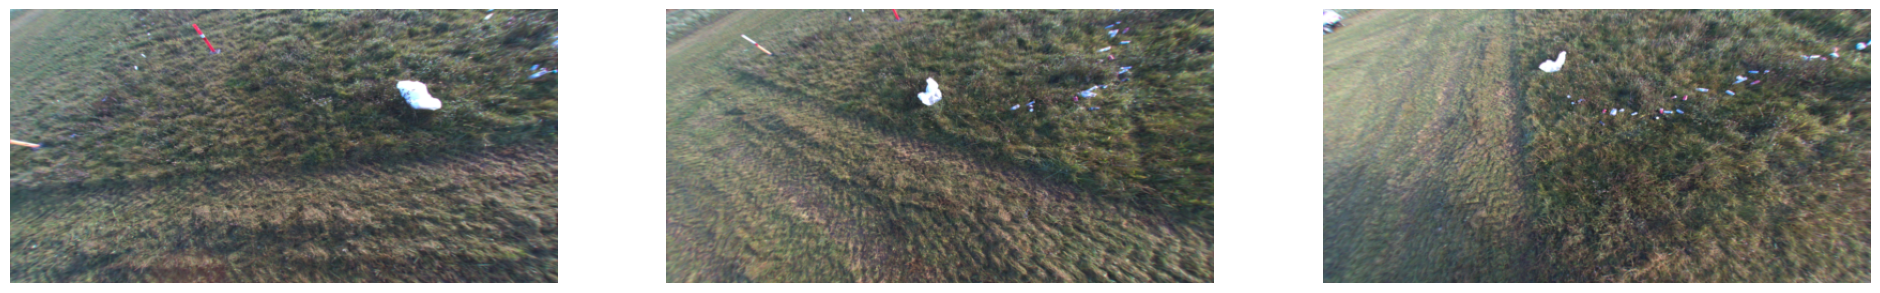

In [12]:
#test_image_1 = test_image_1.permute(1, 2, 0).cpu().numpy()
#test_image_2 = test_image_2.permute(1, 2, 0).cpu().numpy()
#test_image_3 = test_image_3.permute(1, 2, 0).cpu().numpy()

display_images_side_by_side(images=[test_image_1, test_image_2, test_image_3], titles=['','', ''], config_cmap=[None, None, None])

In [13]:
data = data.permute(0, 3, 1, 2)  # From (3, 256, 512, 3) to (3, 3, 256, 512)

data = data.cpu() 

with torch.no_grad():
    recon = model(data)

print(recon.shape)

torch.Size([3, 3, 256, 512])


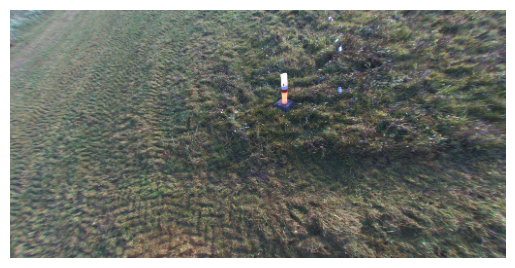

In [52]:
import cv2

img = cv2.imread('/home/maria/Downloads/realsyn_good/1036_original.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.imshow(img)

In [49]:
model = 'realsyn'
path = '/home/maria/Downloads/realsyn_good/'

In [74]:
def read_image(path_to_image: str, mask_image: bool, scale: bool=False):
    
    img = Image.open(path_to_image)

    if mask_image:
        #img = img.converter("L") # greyscale
        binary_mask = np.array(img) > 127
        return binary_mask.astype(np.uint8)

    img = np.array(img.convert('RGB'))
    if scale:
        return img.astype('double') / 255.0

    return img

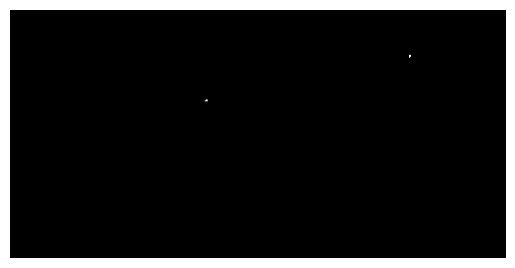

In [104]:
img = read_image(path_to_image='/home/maria/Downloads/cutpaste_good/1023_predicted_mask_recon.png', mask_image=True)
#img_anom = read_image(path_to_image='/home/maria/Downloads/baseline_good/1047_anomaly_map.png', mask_image=False)
plt.axis('off')
plt.imshow(img, cmap='grey')
#plt.imshow(img_anom, cmap='jet', alpha=0.7)

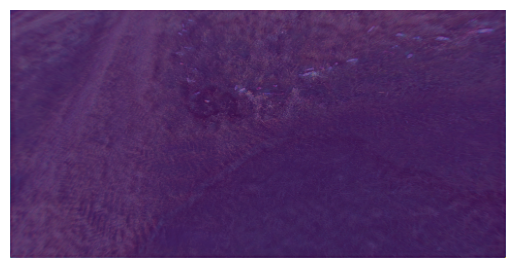

In [ ]:


img = read_image(path_to_image='/home/maria/Downloads/ba_good/1023_original.png', mask_image=False)
img_anom = read_image(path_to_image='/home/maria/Downloads/baseline_good/1023_anomaly_map.png', mask_image=False)
plt.axis('off')
plt.imshow(img)
plt.imshow(img_anom, cmap='jet', alpha=0.7)

TypeError: imread() missing required argument 'filename' (pos 1)

<Figure size 1600x1200 with 0 Axes>

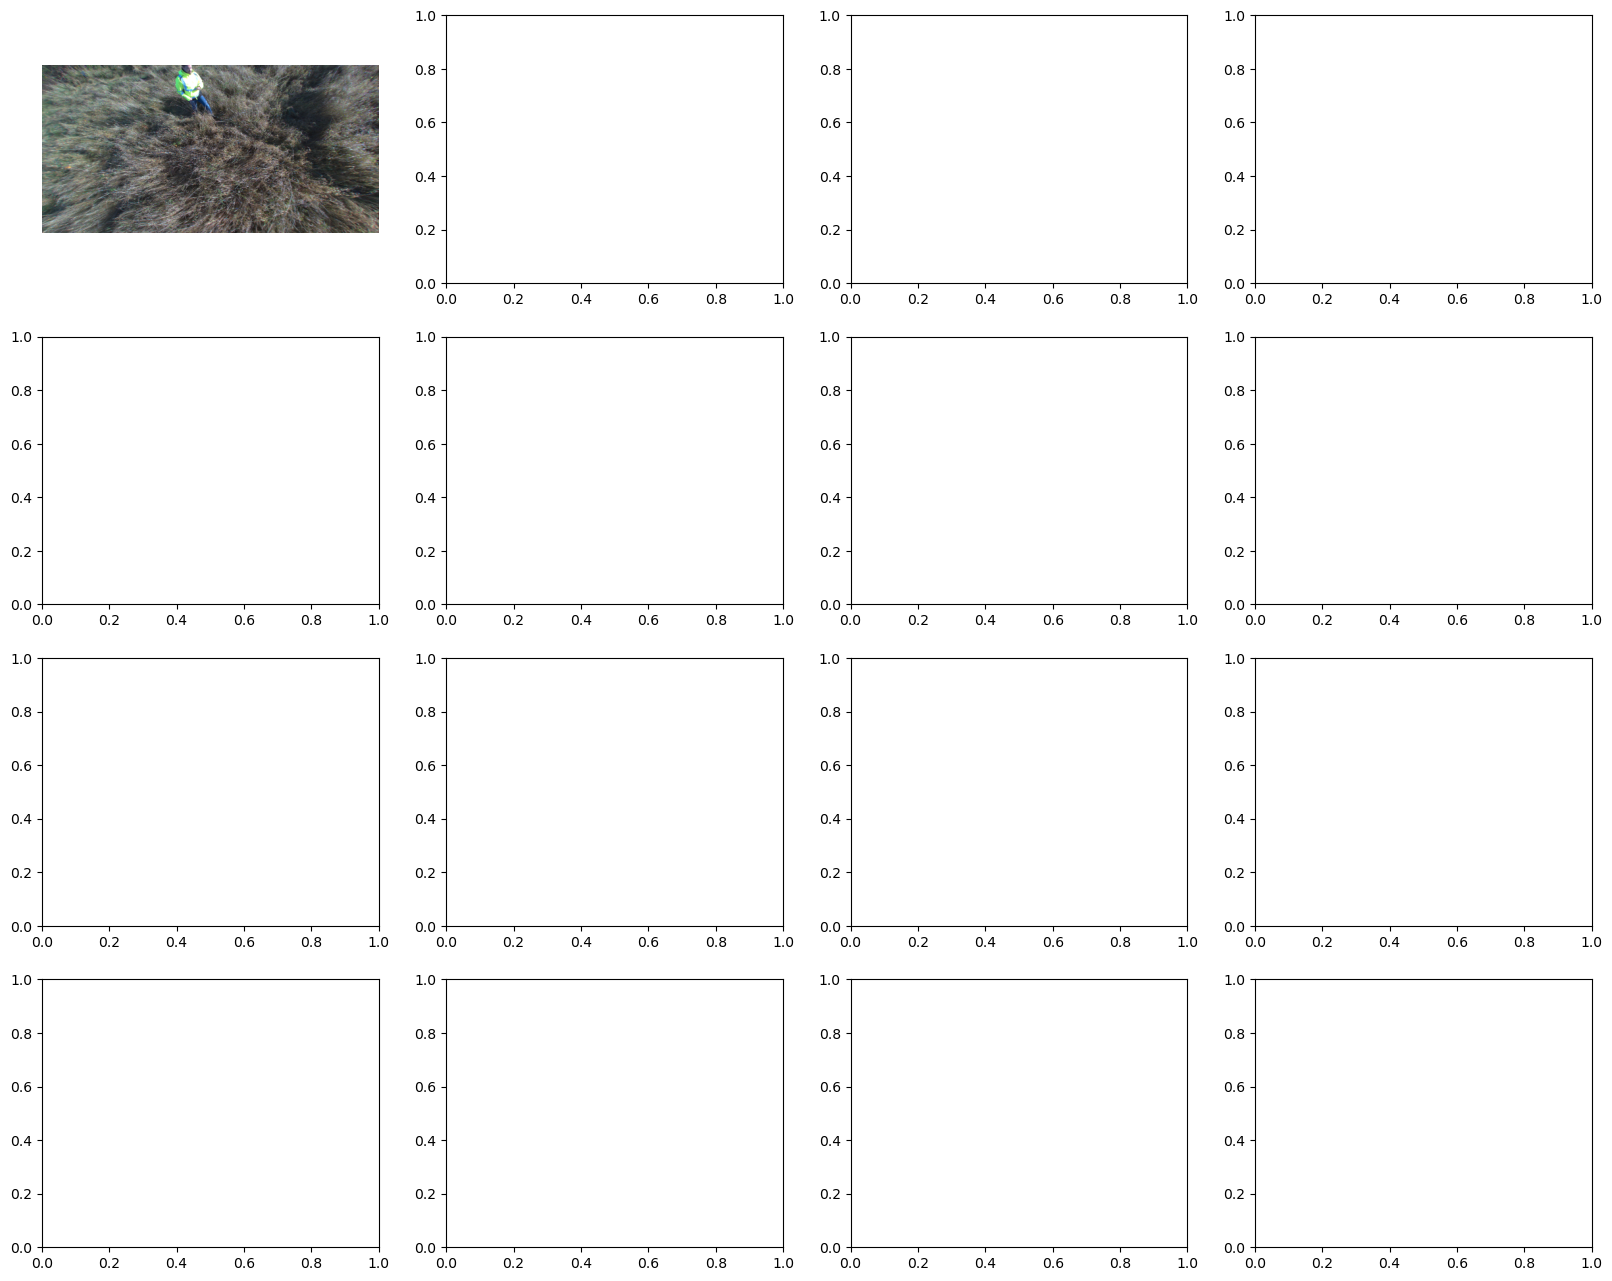

In [62]:
#recon_error =  ((data-recon)**2).mean(axis=1)
#print(recon_error.shape)

#threshold = 0.25  # Adjust this threshold based on your needs
#binary_recon_error = (recon_error > threshold).float()



# Plot data, reconstructions, L2 errors, and binary errors
plt.figure(dpi=250)
fig, ax = plt.subplots(4, 4, figsize=(5 * 4, 4 * 4))

folder_names = ['baseline_good', 'perlin_good','realsyn_good', 'cutpaste_good']
index = 1047

for i in range(4):
    # Original data

    img_o = read_image(path_to_image=f'/home/maria/Downloads/{folder_names[i]}/{index}_original.png', mask_image=False)
    ax[0, i].imshow(img)
    #ax[0, i].set_title("Original")
    ax[0, i].axis('OFF')

    # True Mask
    img = cv2.imread(path_to_image=f'/home/maria/Downloads/{folder_names[i]}/{index}_true_mask.png', mask_image=True)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax[1, i].imshow(img, cmap='grey')
    #ax[0, i].set_title("Reconstructed")
    ax[1, i].axis('OFF')

    # Anomaly map
    img_ano = cv2.imread(path_to_image=f'/home/maria/Downloads/{folder_names[i]}/{index}_anomaly_map.png', mask_image=False)
    #img_ano = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax[2, i].imshow(img_o)
    ax[2, i].imshow(img_ano, cmap='jet', alpha=.5)
    ax[2, i].set_title("")
    ax[2, i].axis('OFF')

    # L2 Reconstruction Error
    img = cv2.imread(path_to_image=f'/home/maria/Downloads/{folder_names[i]}/{index}_predicted_mask_recon.png', mask_image=False)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax[1, i].imshow(img, cmap='grey')
    #ax[0, i].set_title("Reconstructed")
    ax[1, i].axis('OFF')

plt.tight_layout()
plt.show()

In [25]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# Assuming 'recon_error' and 'binary_recon_error' are already computed
# Placeholder ground truth labels (replace these with your actual labels)
# image_labels: 1 if the entire image contains an anomaly, 0 otherwise
image_labels = np.array([1, 1, 1])  # Example for 3 images

# pixel_labels: binary masks with the same shape as recon_error (3, H, W)
pixel_labels = torch.randint(0, 2, recon_error.shape)  # Random binary ground truth for illustration

# Flatten the pixel-level data for computing pixel-level metrics
recon_error_flat = recon_error.cpu().numpy().flatten()
pixel_labels_flat = pixel_labels.cpu().numpy().flatten()

# ----------------------------
# 1. Compute Image-Level AUROC and Average Precision
# ----------------------------

# Compute mean reconstruction error for each image
image_level_scores = recon_error.mean(dim=(1, 2)).cpu().numpy()

# Compute Image-Level AUROC
image_auroc = roc_auc_score(image_labels, image_level_scores)

# Compute Image-Level Average Precision
image_ap = average_precision_score(image_labels, image_level_scores)

print(f"Image-Level AUROC: {image_auroc:.4f}")
print(f"Image-Level Average Precision: {image_ap:.4f}")

# ----------------------------
# 2. Compute Pixel-Level AUROC and Average Precision
# ----------------------------

# Compute Pixel-Level AUROC
pixel_auroc = roc_auc_score(pixel_labels_flat, recon_error_flat)

# Compute Pixel-Level Average Precision
pixel_ap = average_precision_score(pixel_labels_flat, recon_error_flat)

print(f"Pixel-Level AUROC: {pixel_auroc:.4f}")
print(f"Pixel-Level Average Precision: {pixel_ap:.4f}")

Image-Level AUROC: nan
Image-Level Average Precision: 1.0000
Pixel-Level AUROC: 0.5014
Pixel-Level Average Precision: 0.5009


/home/maria/miniconda3/envs/draem/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:375: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


torch.Size([3, 256, 512])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12707637..1.024806].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.120169066..1.0123992].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12972753..1.0484133].


<Figure size 1600x1200 with 0 Axes>

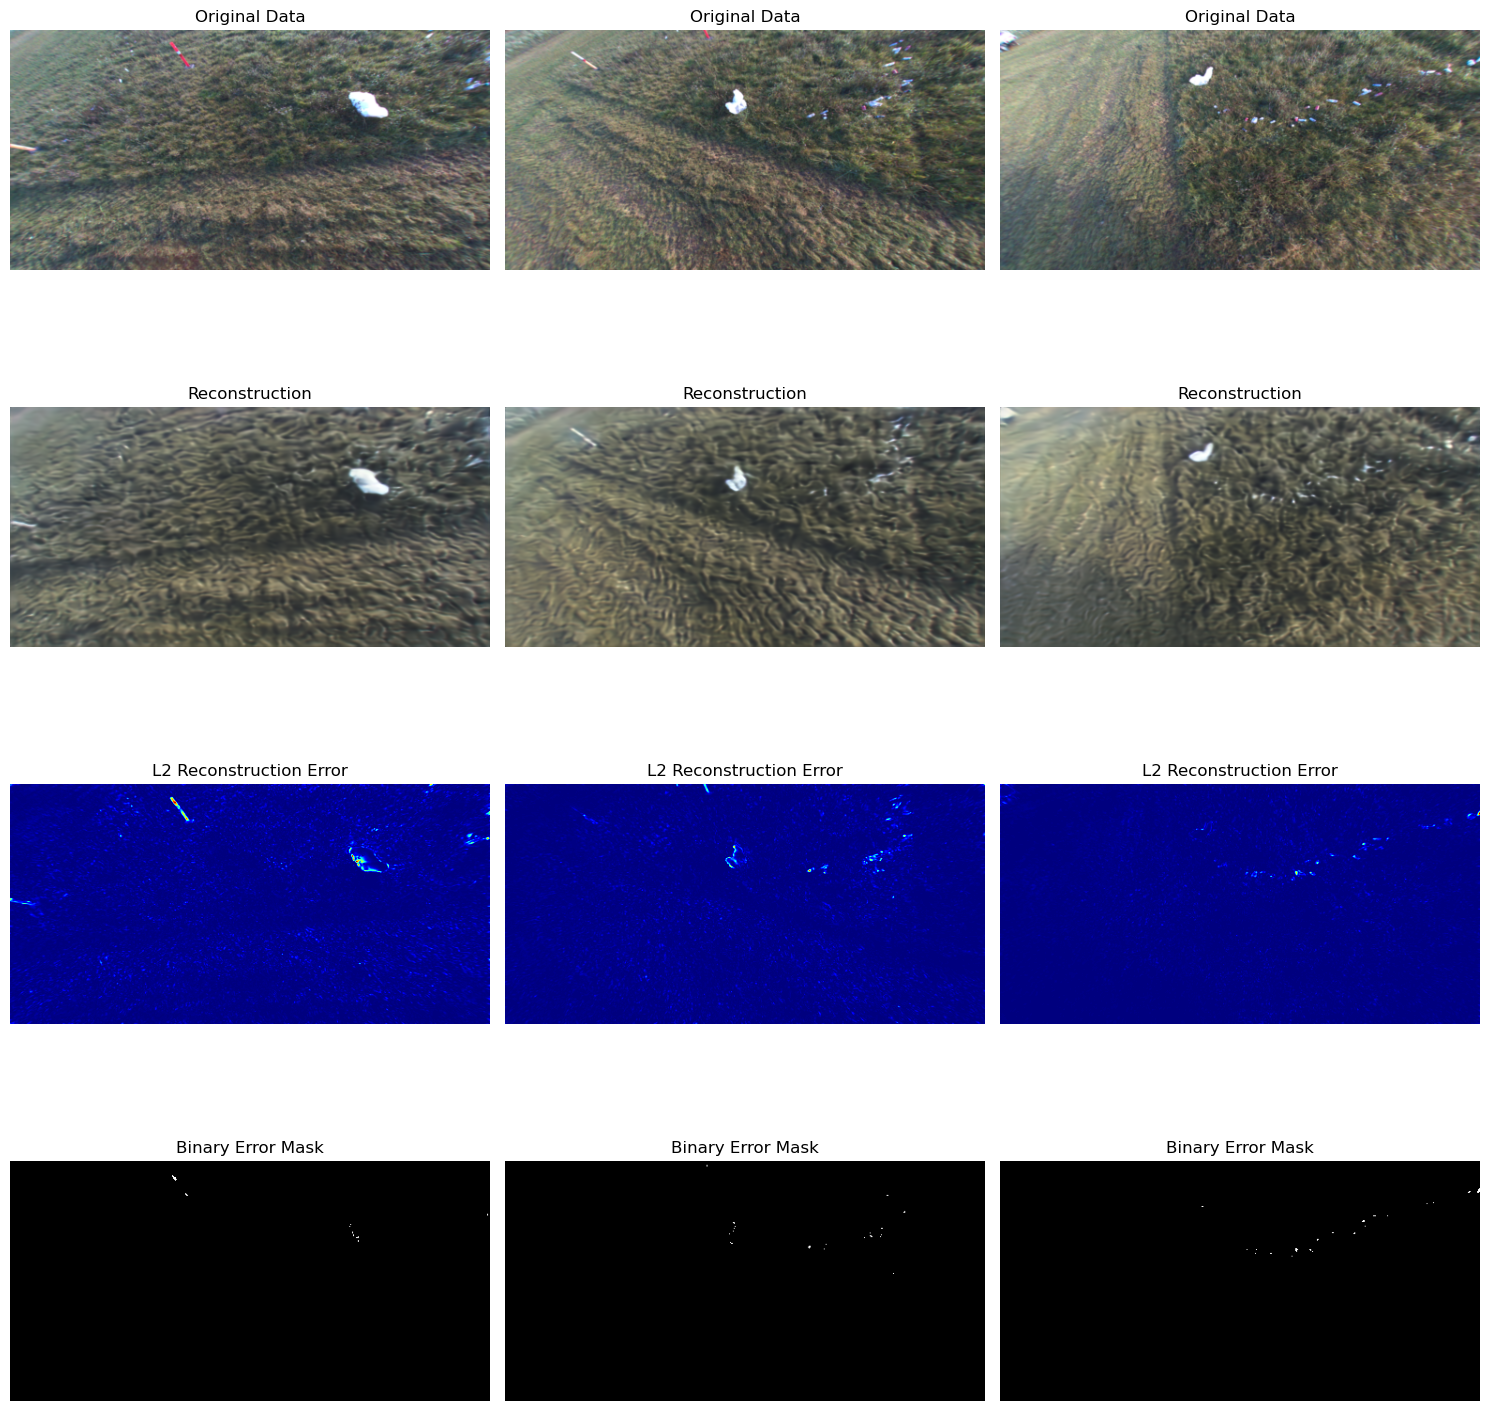

In [56]:
recon_error =  ((data-recon)**2).mean(axis=1)
print(recon_error.shape)

threshold = 0.1  # Adjust this threshold based on your needs
binary_recon_error = (recon_error > threshold).float()



# Plot data, reconstructions, L2 errors, and binary errors
plt.figure(dpi=250)
fig, ax = plt.subplots(4, 3, figsize=(5 * 3, 4 * 4))

for i in range(3):
    # Original data
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[0, i].set_title("Original Data")
    ax[0, i].axis('OFF')

    # Reconstruction
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].set_title("Reconstruction")
    ax[1, i].axis('OFF')

    # L2 Reconstruction Error
    ax[2, i].imshow(recon_error[i].cpu().numpy(), cmap='jet', vmax=torch.max(recon_error[i]))
    ax[2, i].set_title("L2 Reconstruction Error")
    ax[2, i].axis('OFF')

    # Binary Reconstruction Error
    ax[3, i].imshow(binary_recon_error[i].cpu().numpy(), cmap='gray')
    ax[3, i].set_title("Binary Error Mask")
    ax[3, i].axis('OFF')

plt.tight_layout()
plt.show()

torch.Size([3, 256, 512])


<Figure size 1600x1200 with 0 Axes>

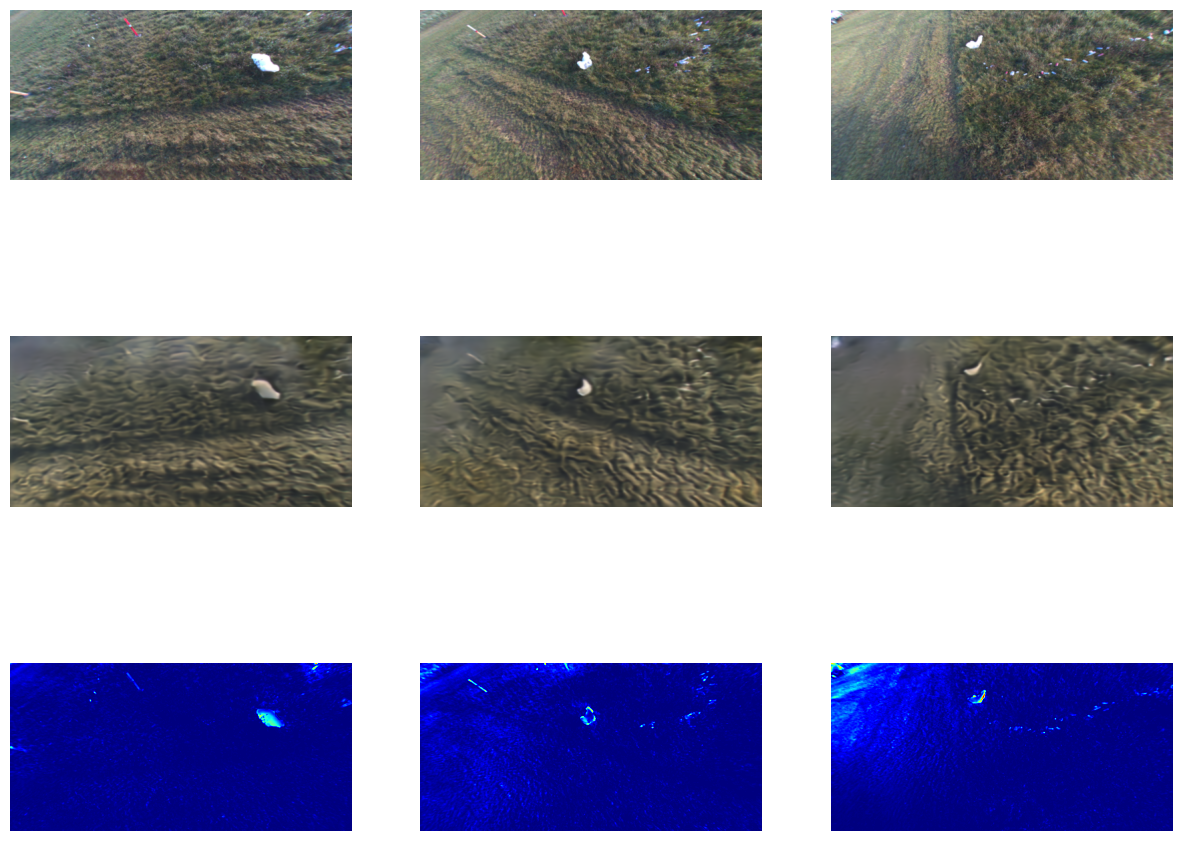

In [28]:
recon_error =  ((data-recon)**2).mean(axis=1)
print(recon_error.shape)

plt.figure(dpi=250)
fig, ax = plt.subplots(3, 3, figsize=(5*3, 4*3))
for i in range(3):
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[2, i].imshow(recon_error[i][0:-10,0:-10].cpu().numpy(), cmap='jet',vmax= torch.max(recon_error[i]))
    ax[0, i].axis('OFF')
    ax[1, i].axis('OFF')
    ax[2, i].axis('OFF')
plt.show()

Reconstruction Error Shape: torch.Size([3, 64, 64])


<Figure size 1600x1200 with 0 Axes>

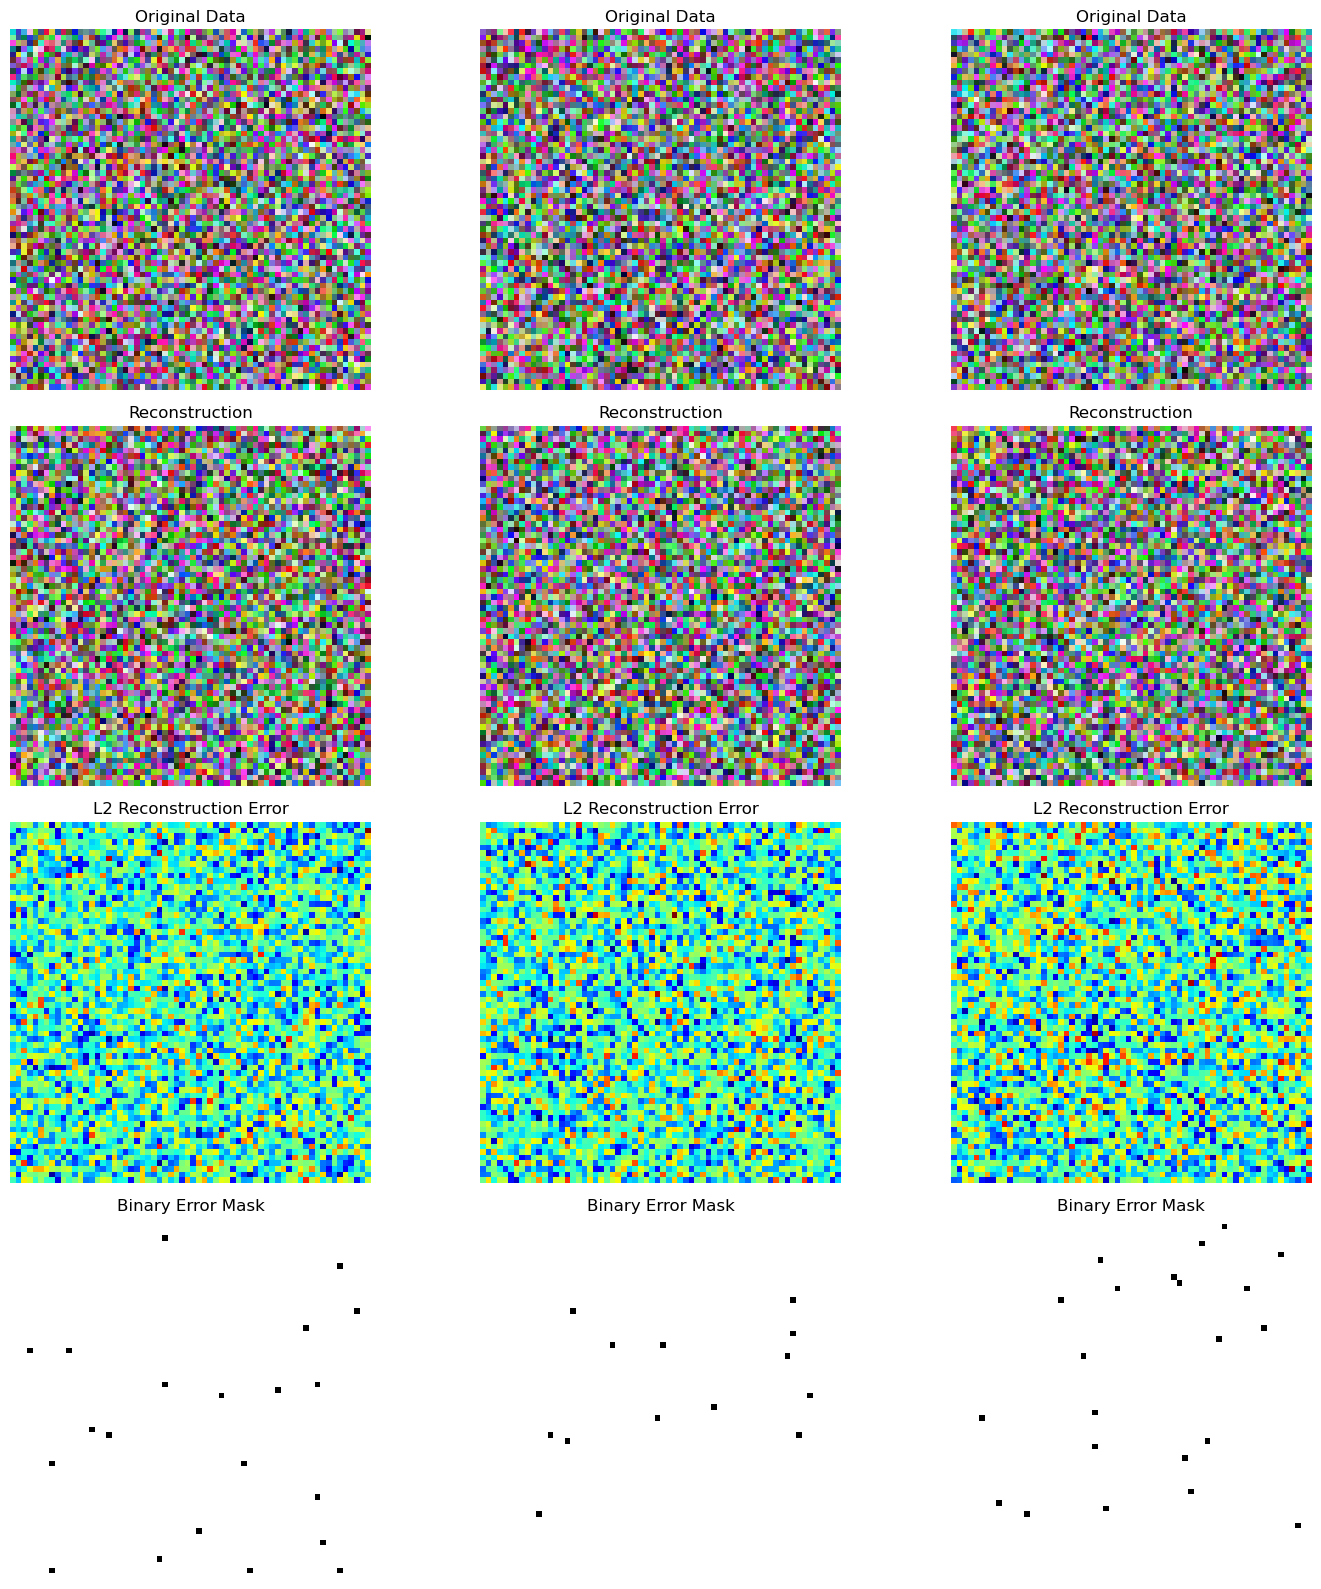

In [38]:
# Example tensors for data and recon (you can replace these with your actual tensors)
# Assuming data and recon are tensors of shape (batch_size, channels, height, width)

# Compute L2 reconstruction error
recon_error = torch.sqrt(((data - recon) ** 2).sum(dim=1))  # Sum over the channel dimension
print(f"Reconstruction Error Shape: {recon_error.shape}")

# Define a threshold for binary error mask
threshold = 0.1  # Adjust this threshold based on your needs
binary_recon_error = (recon_error > threshold).float()

# Plot data, reconstructions, L2 errors, and binary errors
plt.figure(dpi=250)
fig, ax = plt.subplots(4, 3, figsize=(5 * 3, 4 * 4))

for i in range(3):
    # Original data
    ax[0, i].imshow(data[i].cpu().numpy().transpose((1, 2, 0)))
    ax[0, i].set_title("Original Data")
    ax[0, i].axis('OFF')

    # Reconstruction
    ax[1, i].imshow(recon[i].cpu().numpy().transpose((1, 2, 0)))
    ax[1, i].set_title("Reconstruction")
    ax[1, i].axis('OFF')

    # L2 Reconstruction Error
    ax[2, i].imshow(recon_error[i].cpu().numpy(), cmap='jet', vmax=torch.max(recon_error[i]))
    ax[2, i].set_title("L2 Reconstruction Error")
    ax[2, i].axis('OFF')

    # Binary Reconstruction Error
    ax[3, i].imshow(binary_recon_error[i].cpu().numpy(), cmap='gray')
    ax[3, i].set_title("Binary Error Mask")
    ax[3, i].axis('OFF')

plt.tight_layout()
plt.show()

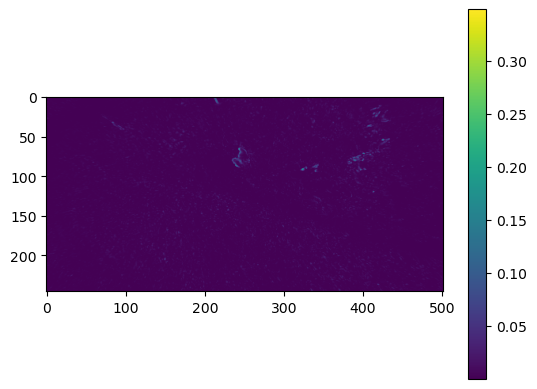

In [55]:
plt.imshow(recon_error[1][0:-10,0:-10].cpu().numpy(),vmax= torch.max(recon_error[i]))
plt.colorbar()